In [1]:
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [175]:
# Values can be supplied by an sbatch job. The defaults preserve interactive use.
name <- Sys.getenv("PLA_DATASET_NAME", unset = "sepsis")
PROJECT_ROOT <- Sys.getenv("PLA_PROJECT_ROOT", unset = "")
GATING_ROOT <- if (nzchar(PROJECT_ROOT)) {
  file.path(PROJECT_ROOT, "src", "gating_automation")
} else {
  normalizePath("..", mustWork = TRUE)
}
source(file.path(GATING_ROOT, "config", "datasets.R"))
source(file.path(GATING_ROOT, "config", "qc_parameters.R"))
QC_VARIANT <- Sys.getenv("PLA_QC_VARIANT", unset = "no_adt")

if (!QC_VARIANT %in% c("adt", "adt_tuned", "no_adt")) {
  stop("Unknown QC variant: ", QC_VARIANT, ". Expected 'adt', 'adt_tuned', or 'no_adt'.")
}

OUT_DIR <- if (nzchar(PROJECT_ROOT)) {
  file.path(PROJECT_ROOT, "results", "sample_qc", name, QC_VARIANT)
} else {
  file.path("..", "..", "results", "sample_qc", name, QC_VARIANT)
}

FILTERED_DATASET_PATH <- file.path(
  OUT_DIR,
  "dataset_usable_sample_celltype_pairs.rds"
)

if (!file.exists(FILTERED_DATASET_PATH)) {
  stop("Filtered input RDS file not found: ", FILTERED_DATASET_PATH)
}

dataset <- readRDS(FILTERED_DATASET_PATH)

# Batch jobs select ADT_ADTnorm_<dataset>; interactive runs keep the ADT default.
ADT_ASSAY <- Sys.getenv("PLA_ADT_ASSAY", unset = "ADT")

if (!ADT_ASSAY %in% Assays(dataset)) {
  stop(
    "ADT assay not found: ", ADT_ASSAY,
    ". Available assays: ", paste(Assays(dataset), collapse = ", ")
  )
}

message("Using ADT assay: ", ADT_ASSAY)
meta <- dataset@meta.data

In [176]:
head(meta$lineage)

[1] B cells     CD4 T cells CD8 T cells CD4 T cells CD4 T cells CD4 T cells
8 Levels: DCs NK cells Unassigned neutrophils CD8 T cells ... Monocytes

In [177]:
colnames(meta)

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

In [ ]:
# -----------------------------
# Automatic platelet ADT marker mapping
# -----------------------------

strip_duplicate_suffix <- function(x) {
  # Remove Seurat-style duplicate suffixes such as ".1", "-1", "_1"
  # Example: ITGA2B.1 -> ITGA2B; CD4-1 -> CD4
  sub("([._-])\\d+$", "", x)
}

normalize_marker_name <- function(x) {
  # Normalize marker names for exact matching
  x <- toupper(x)
  x <- gsub("[^A-Z0-9]", "", x)
  return(x)
}

extract_adt_target <- function(x) {
  # Remove Seurat suffix first
  x <- strip_duplicate_suffix(x)

  # Remove vendor/barcode prefixes such as C0353-CD41
  # Example: C0353-CD41 -> CD41
  x <- sub("^C[0-9]+[-_]", "", x, ignore.case = TRUE)

  return(x)
}

find_adt_feature <- function(aliases, adt_features) {
  # Create two matching layers:
  # 1. full feature name, e.g. ITGA2B.1 -> ITGA2B
  # 2. extracted target, e.g. C0353-CD41 -> CD41

  clean_full_features <- normalize_marker_name(strip_duplicate_suffix(adt_features))
  clean_target_features <- normalize_marker_name(extract_adt_target(adt_features))
  clean_aliases <- normalize_marker_name(aliases)

  for (alias in clean_aliases) {
    # Prefer exact target match, e.g. CD41 in C0353-CD41
    hit_target <- which(clean_target_features == alias)

    if (length(hit_target) > 0) {
      return(adt_features[hit_target[1]])
    }

    # Fallback: exact full-name match, e.g. ITGA2B.1
    hit_full <- which(clean_full_features == alias)

    if (length(hit_full) > 0) {
      return(adt_features[hit_full[1]])
    }
  }

  return(NA_character_)
}

marker_aliases <- PLA_MARKER_ALIASES

  adt_features <- rownames(dataset[[ADT_ASSAY]])

  platelet_marker_map <- tibble::tibble(
    marker_label = names(marker_aliases),
    adt_feature = vapply(
      marker_aliases,
      find_adt_feature,
      character(1),
      adt_features = adt_features
    )
  ) %>%
    dplyr::mutate(
      adt_feature = as.character(unname(adt_feature))
    )

print(platelet_marker_map)

# A tibble: 5 × 2
  marker_label adt_feature
  <chr>        <chr>      
1 CD41         C0353-CD41 
2 CD42b        C0216-CD42b
3 CD61         NA         
4 CD62P        C0218-CD62P
5 CLEC2        NA         


In [179]:
adt_features

[1] "S1"                "S2"                "S3"               
  [4] "S4"                "C0005-CD80"        "C0006-CD86"       
  [7] "C0007-CD274"       "C0008-CD273"       "C0009-CD275"      
 [10] "C0020-CD270"       "C0021-CD252"       "C0022-CD137L"     
 [13] "C0023-CD155"       "C0024-CD112"       "C0026-CD47"       
 [16] "C0027-CD70"        "C0028-CD30"        "C0029-CD48"       
 [19] "C0031-CD40"        "C0032-CD154"       "C0033-CD52"       
 [22] "C0034-CD3"         "C0046-CD8"         "C0047-CD56"       
 [25] "C0050-CD19"        "C0052-CD33"        "C0053-CD11c"      
 [28] "C0054-CD34"        "C0056-CD269"       "C0058-HLA-ABC"    
 [31] "C0061-CD117"       "C0062-CD10"        "C0063-CD45RA"     
 [34] "C0064-CD123"       "C0066-CD7"         "C0068-CD105"      
 [37] "C0069-CD201"       "C0070-CD49f"       "C0071-CD194"      
 [40] "C0072-CD4"         "C0073-CD44"        "C0081-CD14"       
 [43] "C0083-CD16"        "C0085-CD25"        "C0087-CD45RO"     
 [46] "C0088-CD279"       "C0089-TIGIT"       "C0090-IgG1"       
 [49] "C0091-IgG2a"       "C0092-IgG2b"       "C0095-IgG2b"      
 [52] "C0100-CD20"        "C0101-CD335"       "C0102-CD294"      
 [55] "C0103-CD45R-B220"  "C0123-CD326"       "C0124-CD31"       
 [58] "C0127-Podoplanin"  "C0128-CD140a"      "C0129-CD140b"     
 [61] "C0132-EGFR"        "C0134-CD146"       "C0135-CD324"      
 [64] "C0136-IgM"         "C0138-CD5"         "C0139-TCR"        
 [67] "C0140-CD183"       "C0141-CD195"       "C0142-CD32"       
 [70] "C0143-CD196"       "C0144-CD185"       "C0145-CD103"      
 [73] "C0146-CD69"        "C0147-CD62L"       "C0148-CD197"      
 [76] "C0149-CD161"       "C0151-CD152"       "C0152-CD223"      
 [79] "C0153-KLRG1"       "C0154-CD27"        "C0155-CD107a"     
 [82] "C0156-CD95"        "C0158-CD134"       "C0159-HLA-DR"     
 [85] "C0160-CD1c"        "C0161-CD11b"       "C0162-CD64"       
 [88] "C0163-CD141"       "C0164-CD1d"        "C0165-CD314"      
 [91] "C0166-CD66b"       "C0167-CD35"        "C0168-CD57"       
 [94] "C0169-CD366"       "C0170-CD272"       "C0171-CD278"      
 [97] "C0174-CD58"        "C0175-CD96"        "C0176-CD39"       
[100] "C0177-CD178"       "C0179-CX3CR1"      "C0180-CD24"       
[103] "C0181-CD21"        "C0185-CD11a"       "C0187-CD79b"      
[106] "C0188-CD66a-c-e"   "C0189-CD244"       "C0196-CD235ab"    
[109] "C0205-CD206"       "C0206-CD169"       "C0207-CD370"      
[112] "C0208-XCR1"        "C0213-Notch"       "C0214-Integrin"   
[115] "C0215-CD268"       "C0216-CD42b"       "C0217-CD54"       
[118] "C0218-CD62P"       "C0219-CD119"       "C0224-TCR"        
[121] "C0233-Notch3"      "C0236-IgG1"        "C0238-IgG2a"      
[124] "C0241-Hamster-IgG" "C0245-CD106"       "C0246-CD122"      
[127] "C0247-CD267"       "C0248-CD62E"       "C0352-C0352"      
[130] "C0353-CD41"        "C0355-CD137"       "C0356-CD254"      
[133] "C0358-CD163"       "C0359-CD83"        "C0360-CD357"      
[136] "C0363-CD124"       "C0364-CD13"        "C0366-CD184"      
[139] "C0367-CD2"         "C0368-CD226"       "C0369-CD29"       
[142] "C0370-CD303"       "C0371-CD49b"       "C0373-CD81"       
[145] "C0374-CD98"        "C0375-IgG"         "C0384-IgD"        
[148] "C0385-CD18"        "C0386-CD28"        "C0387-TSLPR"      
[151] "C0389-CD38"        "C0390-CD127"       "C0391-CD45"       
[154] "C0393-CD22"        "C0394-CD71"        "C0395-B7-H4"      
[157] "C0396-CD26"        "C0399-CD204"       "C0400-CD144"      
[160] "C0402-CD1a"        "C0406-CD304"       "C0407-CD36"       
[163] "C0420-CD158"       "C0433-CD325"       "C0437-CD207"      
[166] "C0575-CD49a"       "C0576-CD49d"       "C0577-CD73"       
[169] "C0581-TCR"         "C0582-TCR"         "C0583-TCR"        
[172] "C0584-TCR"         "C0590-CD305"       "C0591-LOX-1"      
[175] "C0592-CD158b"      "C0597-CD209"       "C0599-CD158e1"    
[178] "C0600-CD158f"      "C0801-CD337"       "C0802-CD336"      
[181] "C0828-CD307d"      "C0829-CD307e"  

# Analysis

In [180]:
pla_col <- "pla_status"

dataset_config <- get_pla_dataset_config(name)
group_col <- dataset_config$sample_col

if (is.na(group_col)) {
  stop("No grouping column found. Expected one of: donor_id, sample_id, sample.")
}

# Remove missing markers and remove vector names
platelet_marker_map <- platelet_marker_map %>%
  dplyr::filter(!is.na(adt_feature)) %>%
  dplyr::mutate(
    adt_feature = as.character(unname(adt_feature))
  ) %>%
  dplyr::distinct(marker_label, adt_feature)

platelet_features <- unname(platelet_marker_map$adt_feature)

print(platelet_marker_map)
print(platelet_features)

DefaultAssay(dataset) <- ADT_ASSAY

adt_df <- FetchData(
  dataset,
  vars = c(platelet_features, group_col, pla_col, "lineage")
) %>%
  tibble::rownames_to_column("cell_id") %>%
  dplyr::rename(
    group_id = dplyr::all_of(group_col),
    pla_status = dplyr::all_of(pla_col),
    lineage = dplyr::all_of("lineage")
  )

adt_long <- adt_df %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(platelet_features),
    names_to = "adt_feature",
    values_to = "expression"
  ) %>%
  dplyr::left_join(
    platelet_marker_map,
    by = "adt_feature"
  )

# A tibble: 3 × 2
  marker_label adt_feature
  <chr>        <chr>      
1 CD41         C0353-CD41 
2 CD42b        C0216-CD42b
3 CD62P        C0218-CD62P
[1] "C0353-CD41"  "C0216-CD42b" "C0218-CD62P"


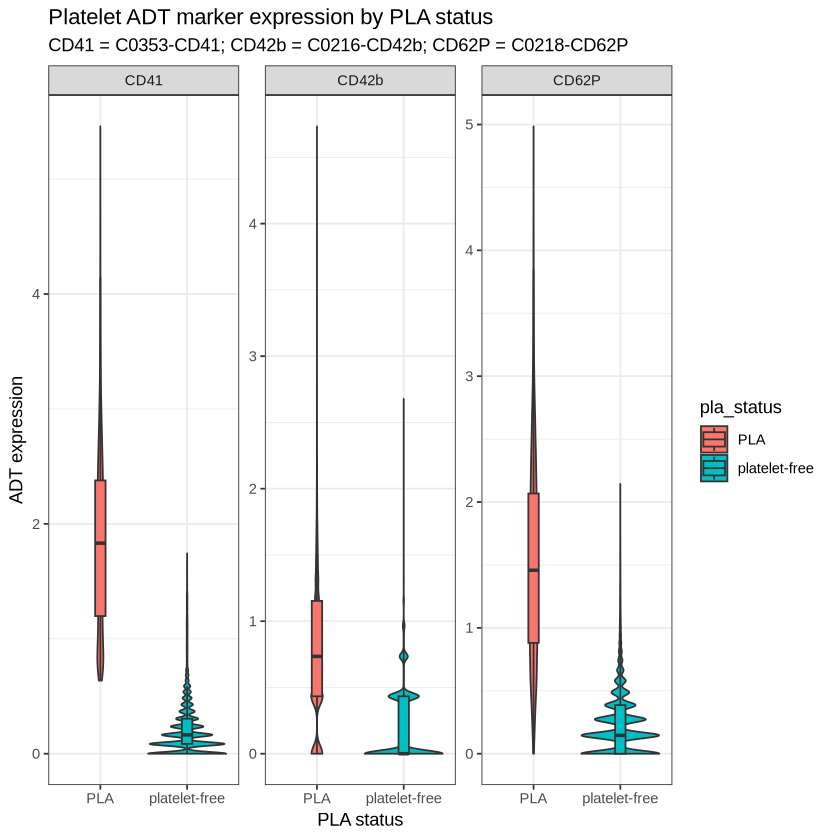

In [181]:
p_marker_status <- adt_long %>%
  dplyr::filter(!is.na(pla_status)) %>%
  ggplot(aes(x = pla_status, y = expression, fill = pla_status)) +
  geom_violin(trim = TRUE) +
  geom_boxplot(width = 0.12, outlier.shape = NA) +
  facet_wrap(~ marker_label, scales = "free_y") +
  theme_bw() +
  labs(
    title = "Platelet ADT marker expression by PLA status",
    subtitle = paste(
      paste0(platelet_marker_map$marker_label, " = ", platelet_marker_map$adt_feature),
      collapse = "; "
    ),
    x = "PLA status",
    y = "ADT expression"
  )

print(p_marker_status)

ggsave(
  file.path(OUT_DIR, "08_ADT_platelet_markers_by_PLA_status.png"),
  p_marker_status,
  width = 9,
  height = 5,
  dpi = 300
)

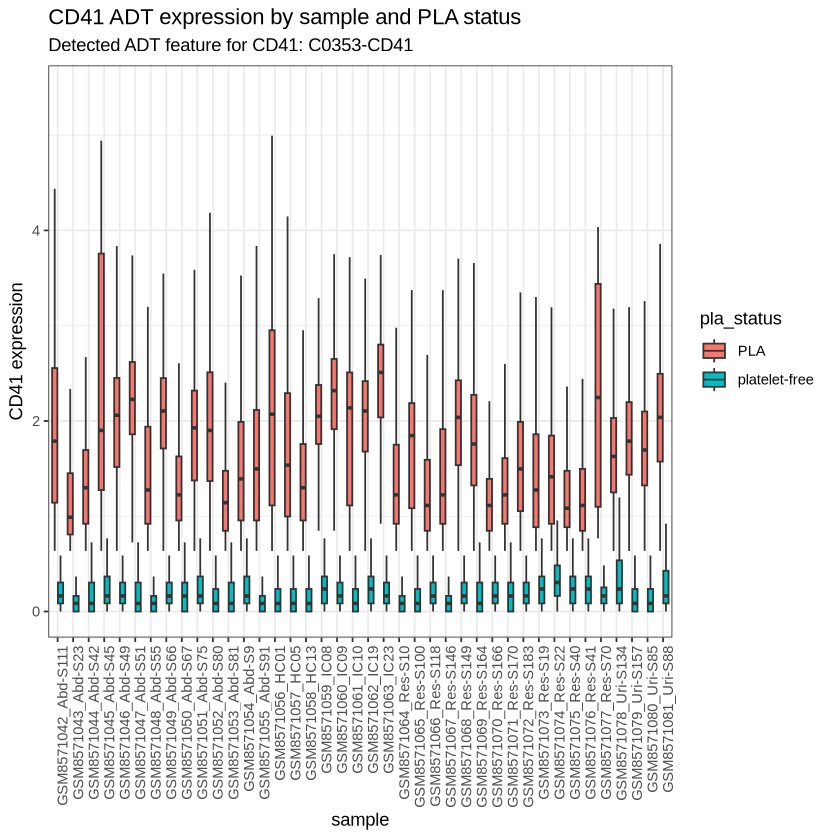

In [182]:
p_cd41_donor <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  ggplot(aes(x = group_id, y = expression, fill = pla_status)) +
  geom_boxplot(outlier.shape = NA) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(
    title = paste0(
      "CD41 ADT expression by ",
      group_col,
      " and PLA status"
    ),
    subtitle = paste0(
      "Detected ADT feature for CD41: ",
      platelet_marker_map$adt_feature[platelet_marker_map$marker_label == "CD41"]
    ),
    x = group_col,
    y = "CD41 expression"
  )

print(p_cd41_donor)

ggsave(
  file.path(OUT_DIR, "09_CD41_by_sample_or_donor_and_PLA_status.png"),
  p_cd41_donor,
  width = 11,
  height = 5,
  dpi = 300
)

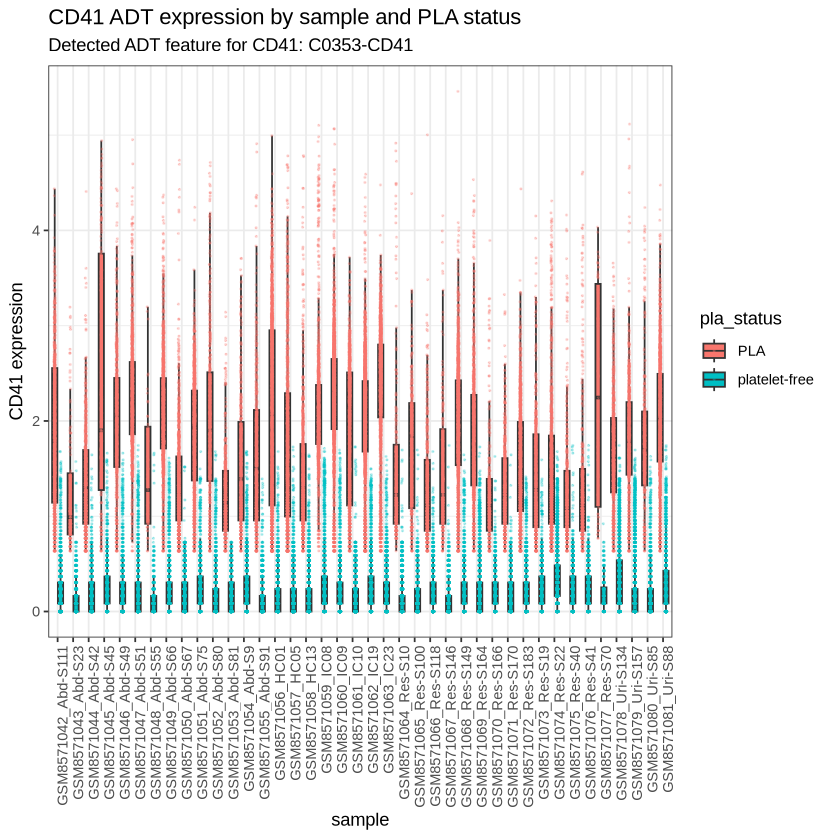

In [183]:
p_cd41_donor <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  ggplot(aes(x = group_id, y = expression, fill = pla_status)) +
  geom_boxplot(outlier.shape = NA) +
  geom_point(
    aes(color = pla_status),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width = 0.75
    ),
    size = 0.25,
    alpha = 0.25
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(
    title = paste0("CD41 ADT expression by ", group_col, " and PLA status"),
    subtitle = paste0(
      "Detected ADT feature for CD41: ",
      platelet_marker_map$adt_feature[platelet_marker_map$marker_label == "CD41"]
    ),
    x = group_col,
    y = "CD41 expression"
  )


print(p_cd41_donor)

ggsave(
  file.path(OUT_DIR, "09_CD41_by_sample_or_donor_and_PLA_status_detailed.png"),
  p_cd41_donor,
  width = 11,
  height = 5,
  dpi = 300
)

In [184]:
adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  group_by(pla_status) %>%
  summarise(
    n = n(),
    min = min(expression, na.rm = TRUE),
    median = median(expression, na.rm = TRUE),
    q75 = quantile(expression, 0.75, na.rm = TRUE),
    q90 = quantile(expression, 0.90, na.rm = TRUE),
    q95 = quantile(expression, 0.95, na.rm = TRUE),
    q99 = quantile(expression, 0.99, na.rm = TRUE),
    max = max(expression, na.rm = TRUE),
    .groups = "drop"
  )

pla_status,n,min,median,q75,q90,q95,q99,max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PLA,33211,0.6362705,1.8321949,2.3780294,2.8337766,3.1379972,3.943505,5.458857
platelet-free,96628,0.0000000,0.1637198,0.3043684,0.5373917,0.6822698,1.250010,1.742907


In [185]:
cd41_stats <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  summarise(
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pf_above_pla_median = mean(
      expression[pla_status == "platelet-free"] >= pla_median,
      na.rm = TRUE
    )
  )

print(cd41_stats)

# A tibble: 1 × 2
  pla_median pf_above_pla_median
       <dbl>               <dbl>
1       1.83                   0


In [186]:
cd41_thresholds <- adt_long %>%
  filter(marker_label == "CD41", !is.na(pla_status)) %>%
  summarise(
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pla_q75 = quantile(expression[pla_status == "PLA"], 0.75, na.rm = TRUE)
  )

print(cd41_thresholds)

# A tibble: 1 × 3
  pla_q25 pla_median pla_q75
    <dbl>      <dbl>   <dbl>
1    1.20       1.83    2.38


In [187]:
pla_q25 <- cd41_thresholds$pla_q25

adt_long %>%
  filter(marker_label == "CD41", pla_status == "platelet-free") %>%
  summarise(
    n_platelet_free = n(),
    n_pf_above_pla_q25 = sum(expression >= pla_q25, na.rm = TRUE),
    frac_pf_above_pla_q25 = mean(expression >= pla_q25, na.rm = TRUE)
  )

n_platelet_free,n_pf_above_pla_q25,frac_pf_above_pla_q25
<int>,<int>,<dbl>
96628,1219,0.01261539


In [188]:
head(adt_long)

cell_id,group_id,pla_status,lineage,adt_feature,expression,marker_label
<chr>,<chr>,<chr>,<fct>,<chr>,<dbl>,<chr>
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042_Abd-S111,platelet-free,B cells,C0353-CD41,0.08520668,CD41
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042_Abd-S111,platelet-free,B cells,C0216-CD42b,0.96548990,CD42b
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042_Abd-S111,platelet-free,B cells,C0218-CD62P,0.00000000,CD62P
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042_Abd-S111,platelet-free,CD4 T cells,C0353-CD41,0.53739170,CD41
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042_Abd-S111,platelet-free,CD4 T cells,C0216-CD42b,0.00000000,CD42b
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042_Abd-S111,platelet-free,CD4 T cells,C0218-CD62P,0.38589304,CD62P


In [189]:
marker_qc_stats <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label)) %>%
  group_by(marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    pla_q75 = quantile(expression[pla_status == "PLA"], 0.75, na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    platelet_free_q95 = quantile(expression[pla_status == "platelet-free"], 0.95, na.rm = TRUE),
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= pla_q25,
      na.rm = TRUE
    ),
    platelet_free_above_pla_median = mean(
      expression[pla_status == "platelet-free"] >= pla_median,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(marker_label)

print(marker_qc_stats, n = Inf, width = Inf)

write.csv(
  marker_qc_stats,
  file.path(OUT_DIR, "10_platelet_marker_qc_stats.csv"),
  row.names = FALSE
)

# A tibble: 3 × 10
  marker_label n_PLA n_platelet_free pla_q25 pla_median pla_q75
  <chr>        <int>           <int>   <dbl>      <dbl>   <dbl>
1 CD41         33211           96628   1.20       1.83     2.38
2 CD42b        33211           96628   0.433      0.734    1.15
3 CD62P        33211           96628   0.881      1.46     2.07
  platelet_free_median platelet_free_q95 platelet_free_above_pla_q25
                 <dbl>             <dbl>                       <dbl>
1                0.164             0.682                      0.0126
2                0                 0.734                      0.345 
3                0.146             0.741                      0.0298
  platelet_free_above_pla_median
                           <dbl>
1                        0      
2                        0.0899 
3                        0.00320


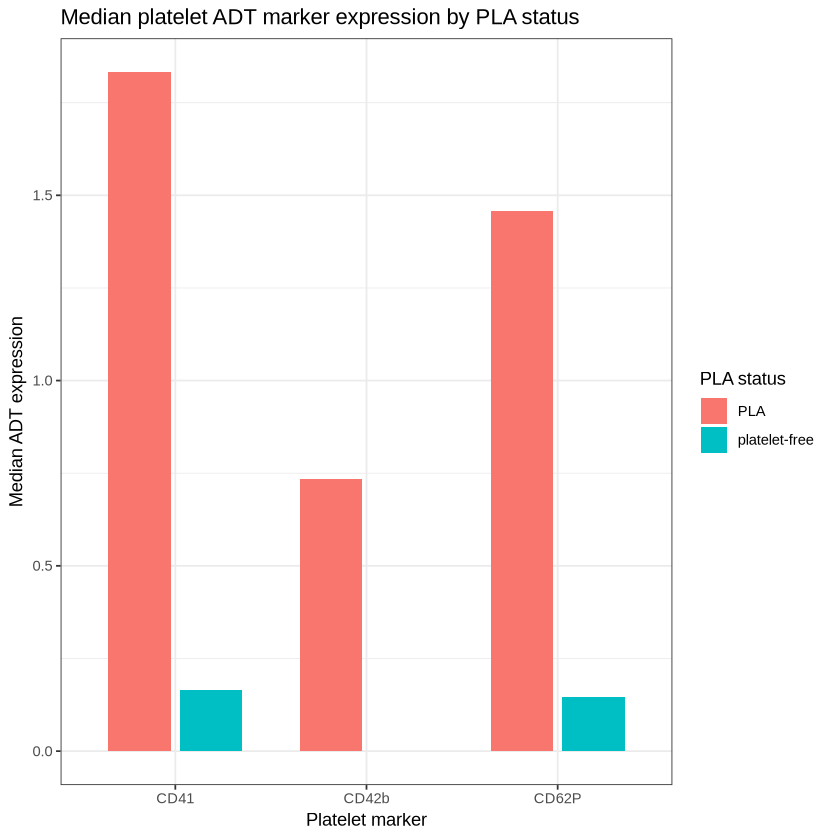

In [190]:
marker_median_plot_df <- marker_qc_stats %>%
  dplyr::select(marker_label, pla_median, platelet_free_median) %>%
  tidyr::pivot_longer(
    cols = c(pla_median, platelet_free_median),
    names_to = "status",
    values_to = "median_expression"
  ) %>%
  dplyr::mutate(
    status = dplyr::recode(
      status,
      pla_median = "PLA",
      platelet_free_median = "platelet-free"
    )
  )

p_marker_medians <- ggplot(
  marker_median_plot_df,
  aes(x = marker_label, y = median_expression, fill = status)
) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  theme_bw() +
  labs(
    title = "Median platelet ADT marker expression by PLA status",
    x = "Platelet marker",
    y = "Median ADT expression",
    fill = "PLA status"
  )

print(p_marker_medians)

ggsave(
  file.path(OUT_DIR, "10_marker_median_expression_by_PLA_status.png"),
  p_marker_medians,
  width = 7,
  height = 4.5,
  dpi = 300
)

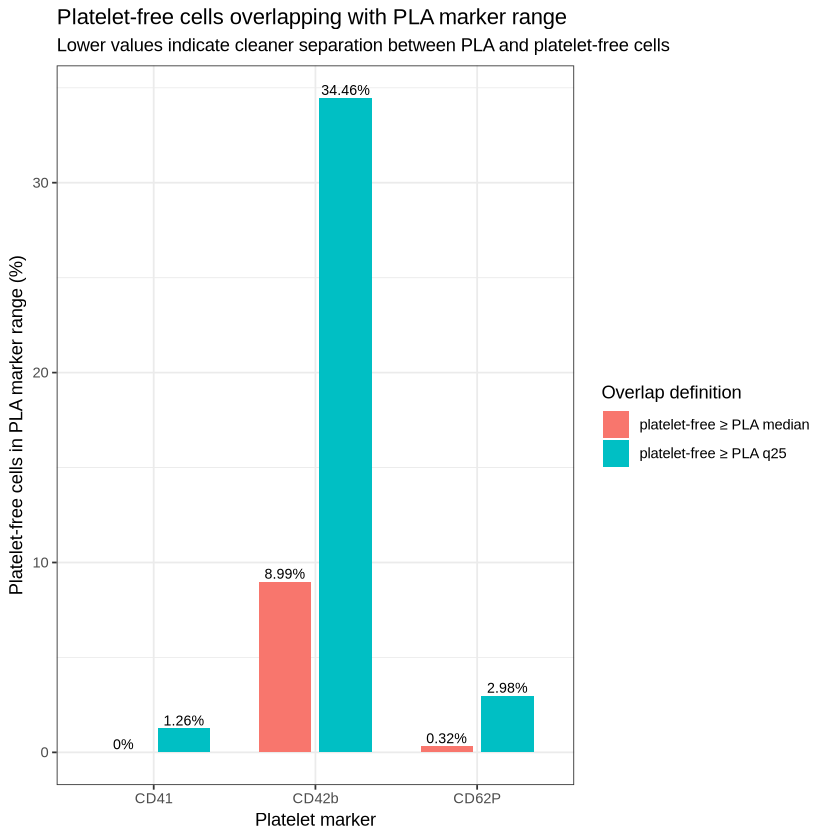

In [191]:
marker_overlap_plot_df <- marker_qc_stats %>%
  dplyr::select(
    marker_label,
    platelet_free_above_pla_q25,
    platelet_free_above_pla_median
  ) %>%
  tidyr::pivot_longer(
    cols = c(platelet_free_above_pla_q25, platelet_free_above_pla_median),
    names_to = "overlap_metric",
    values_to = "fraction"
  ) %>%
  dplyr::mutate(
    overlap_metric = dplyr::recode(
      overlap_metric,
      platelet_free_above_pla_q25 = "platelet-free ≥ PLA q25",
      platelet_free_above_pla_median = "platelet-free ≥ PLA median"
    ),
    percent = fraction * 100
  )

p_marker_overlap <- ggplot(
  marker_overlap_plot_df,
  aes(x = marker_label, y = percent, fill = overlap_metric)
) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  geom_text(
    aes(label = paste0(round(percent, 2), "%")),
    position = position_dodge(width = 0.75),
    vjust = -0.3,
    size = 3
  ) +
  theme_bw() +
  labs(
    title = "Platelet-free cells overlapping with PLA marker range",
    subtitle = "Lower values indicate cleaner separation between PLA and platelet-free cells",
    x = "Platelet marker",
    y = "Platelet-free cells in PLA marker range (%)",
    fill = "Overlap definition"
  )

print(p_marker_overlap)

ggsave(
  file.path(OUT_DIR, "11_platelet_free_overlap_with_PLA_marker_range.png"),
  p_marker_overlap,
  width = 8,
  height = 4.8,
  dpi = 300
)

In [192]:
sample_marker_qc <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label)) %>%
  group_by(group_id, marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    median_difference = pla_median - platelet_free_median,
    platelet_free_q95 = quantile(expression[pla_status == "platelet-free"], 0.95, na.rm = TRUE),
    pla_q25 = quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= pla_q25,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(marker_label, median_difference)

print(sample_marker_qc, n = Inf, width = Inf)

write.csv(
  sample_marker_qc,
  file.path(OUT_DIR, "12_platelet_marker_qc_by_sample.csv"),
  row.names = FALSE
)

# A tibble: 120 × 10
    group_id            marker_label n_PLA n_platelet_free pla_median
    <chr>               <chr>        <int>           <int>      <dbl>
  1 GSM8571075_Res-S40  CD41           490            2241      1.08 
  2 GSM8571076_Res-S41  CD41           430            1945      1.11 
  3 GSM8571043_Abd-S23  CD41           134            1009      0.990
  4 GSM8571066_Res-S118 CD41           521            1946      1.11 
  5 GSM8571070_Res-S166 CD41           305            1318      1.11 
  6 GSM8571073_Res-S19  CD41           568            1590      1.28 
  7 GSM8571053_Abd-S81  CD41           491            1170      1.14 
  8 GSM8571050_Abd-S67  CD41          1042            2329      1.22 
  9 GSM8571071_Res-S170 CD41           581            1622      1.22 
 10 GSM8571074_Res-S22  CD41          1062            3383      1.41 
 11 GSM8571064_Res-S10  CD41           272            3875      1.22 
 12 GSM8571067_Res-S146 CD41           224            2143      1.22 

In [195]:
sample_marker_qc %>%
  filter(
    median_difference < 0.3 |
      platelet_free_above_pla_q25 > 0.10
  ) %>%
  arrange(marker_label, median_difference) %>%
  print(n = Inf, width = Inf)

# A tibble: 45 × 10
   group_id            marker_label n_PLA n_platelet_free pla_median
   <chr>               <chr>        <int>           <int>      <dbl>
 1 GSM8571055_Abd-S91  CD42b          520            2881      0    
 2 GSM8571059_IC08     CD42b         1209            2148      0.734
 3 GSM8571074_Res-S22  CD42b         1062            3383      0.734
 4 GSM8571042_Abd-S111 CD42b          791            2648      0.433
 5 GSM8571043_Abd-S23  CD42b          134            1009      0.433
 6 GSM8571044_Abd-S42  CD42b          760            1765      0.433
 7 GSM8571046_Abd-S49  CD42b          664            2205      0.433
 8 GSM8571050_Abd-S67  CD42b         1042            2329      0.433
 9 GSM8571052_Abd-S80  CD42b          528            2231      0.433
10 GSM8571053_Abd-S81  CD42b          491            1170      0.433
11 GSM8571054_Abd-S9   CD42b          429            2059      0.433
12 GSM8571057_HC05     CD42b         1178            4270      0.433
13 GSM8571058_

In [196]:
lineage_marker_qc <- adt_long %>%
  filter(!is.na(pla_status), !is.na(marker_label), !is.na(lineage)) %>%
  group_by(lineage, marker_label) %>%
  summarise(
    n_PLA = sum(pla_status == "PLA"),
    n_platelet_free = sum(pla_status == "platelet-free"),
    pla_median = median(expression[pla_status == "PLA"], na.rm = TRUE),
    platelet_free_median = median(expression[pla_status == "platelet-free"], na.rm = TRUE),
    median_difference = pla_median - platelet_free_median,
    platelet_free_above_pla_q25 = mean(
      expression[pla_status == "platelet-free"] >= quantile(expression[pla_status == "PLA"], 0.25, na.rm = TRUE),
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(lineage, marker_label)

print(lineage_marker_qc, n = Inf, width = Inf)

write.csv(
  lineage_marker_qc,
  file.path(OUT_DIR, "13_platelet_marker_qc_by_lineage.csv"),
  row.names = FALSE
)

# A tibble: 18 × 8
   lineage     marker_label n_PLA n_platelet_free pla_median
   <fct>       <chr>        <int>           <int>      <dbl>
 1 DCs         CD41           202             100      1.74 
 2 DCs         CD42b          202             100      0.433
 3 DCs         CD62P          202             100      1.34 
 4 NK cells    CD41          2232            8163      1.25 
 5 NK cells    CD42b         2232            8163      0.433
 6 NK cells    CD62P         2232            8163      0.944
 7 CD8 T cells CD41          7457           19305      1.08 
 8 CD8 T cells CD42b         7457           19305      0.433
 9 CD8 T cells CD62P         7457           19305      0.881
10 B cells     CD41           482           20738      2.41 
11 B cells     CD42b          482           20738      1.15 
12 B cells     CD62P          482           20738      2.03 
13 CD4 T cells CD41          5680           45049      1.20 
14 CD4 T cells CD42b         5680           45049      0.433
15 CD

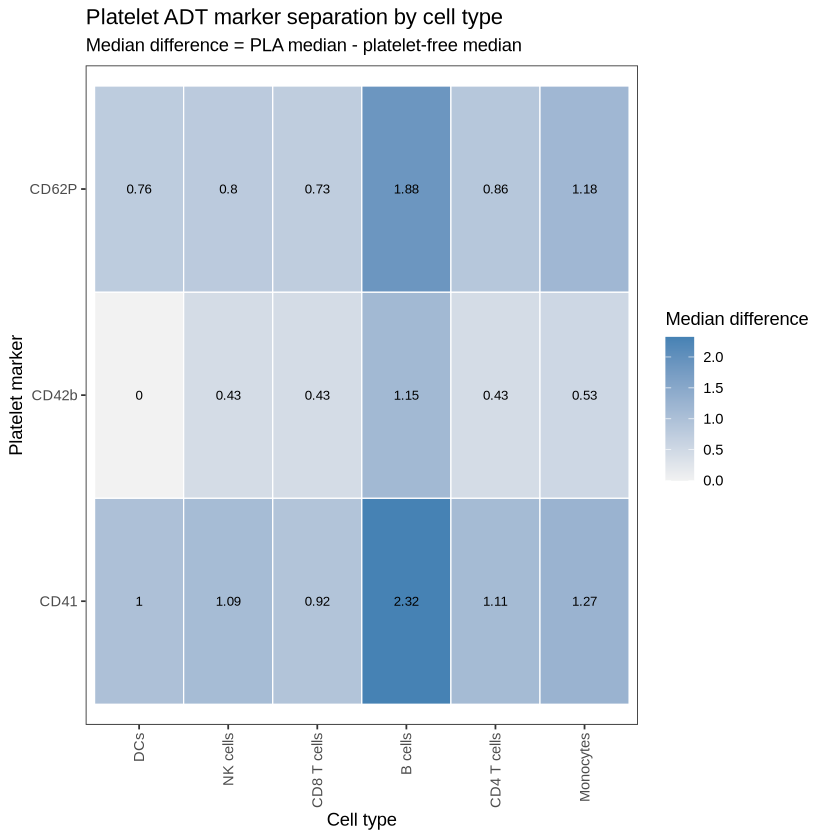

In [197]:
lineage_marker_qc_plot <- lineage_marker_qc %>%
  mutate(
    overlap_percent = platelet_free_above_pla_q25 * 100
  )

p_lineage_median_diff <- ggplot(
  lineage_marker_qc_plot,
  aes(x = lineage, y = marker_label, fill = median_difference)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = round(median_difference, 2)), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "steelblue",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet ADT marker separation by cell type",
    subtitle = "Median difference = PLA median - platelet-free median",
    x = "Cell type",
    y = "Platelet marker",
    fill = "Median difference"
  )

print(p_lineage_median_diff)

ggsave(
  file.path(OUT_DIR, "15_lineage_marker_median_difference_heatmap.png"),
  p_lineage_median_diff,
  width = max(8, length(unique(lineage_marker_qc_plot$lineage)) * 0.5),
  height = 4.5,
  dpi = 300
)

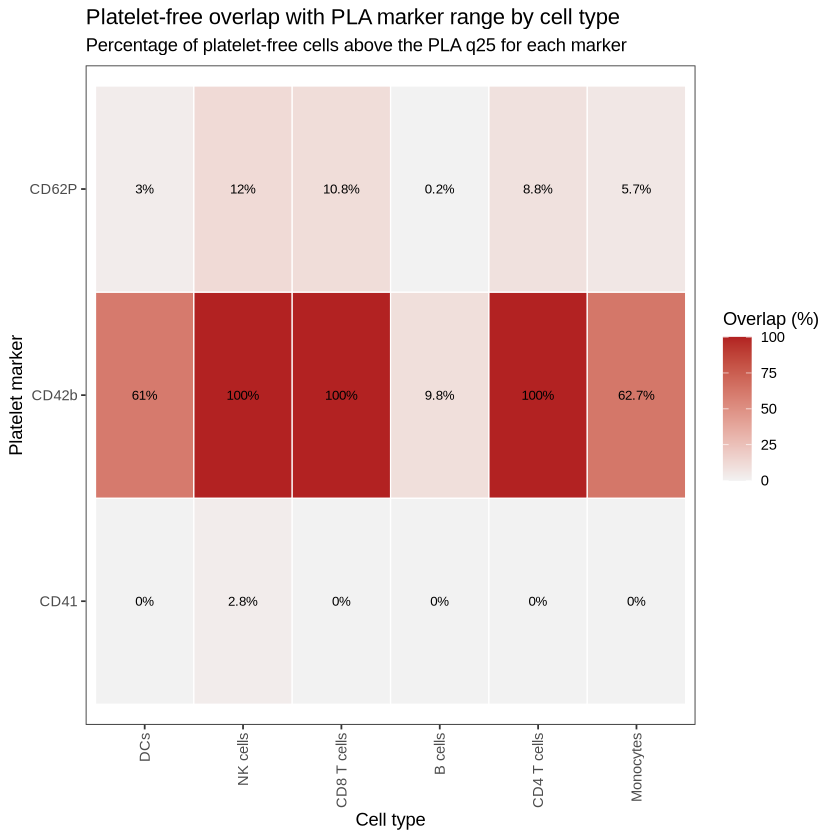

In [198]:
p_lineage_overlap <- ggplot(
  lineage_marker_qc_plot,
  aes(x = lineage, y = marker_label, fill = overlap_percent)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(aes(label = paste0(round(overlap_percent, 1), "%")), size = 2.8) +
  scale_fill_gradient(
    low = "grey95",
    high = "firebrick",
    na.value = "grey80"
  ) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    title = "Platelet-free overlap with PLA marker range by cell type",
    subtitle = "Percentage of platelet-free cells above the PLA q25 for each marker",
    x = "Cell type",
    y = "Platelet marker",
    fill = "Overlap (%)"
  )

print(p_lineage_overlap)

ggsave(
  file.path(OUT_DIR, "16_lineage_platelet_free_overlap_heatmap.png"),
  p_lineage_overlap,
  width = max(8, length(unique(lineage_marker_qc_plot$lineage)) * 0.5),
  height = 4.5,
  dpi = 300
)

In [199]:
head(sample_marker_qc)

group_id,marker_label,n_PLA,n_platelet_free,pla_median,platelet_free_median,median_difference,platelet_free_q95,pla_q25,platelet_free_above_pla_q25
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GSM8571075_Res-S40,CD41,490,2241,1.084083,0.23651481,0.8475679,0.6362705,0.8850368,0.008032129
GSM8571076_Res-S41,CD41,430,1945,1.113720,0.23651481,0.8772056,0.5880527,0.8476399,0.010282776
GSM8571043_Abd-S23,CD41,134,1009,0.989504,0.08520668,0.9042973,0.5373917,0.8087899,0.011892963
GSM8571066_Res-S118,CD41,521,1946,1.113720,0.16371979,0.9500006,0.6362705,0.8476399,0.018499486
GSM8571070_Res-S166,CD41,305,1318,1.113720,0.16371979,0.9500006,0.5880527,0.8476399,0.013657056
GSM8571073_Res-S19,CD41,568,1590,1.275173,0.23651481,1.0386583,0.6362705,0.8850368,0.023899371


# QC

In [ ]:
qc <- PLA_QC_PARAMETERS

core_marker_labels <- qc$core_marker_labels

support_marker_labels <- setdiff(
  unique(platelet_marker_map$marker_label),
  core_marker_labels
)

core_marker_labels <- adt_qc_params$core_marker_labels
support_marker_labels <- setdiff(unique(platelet_marker_map$marker_label), core_marker_labels)

adt_qc_param_table <- tibble::tibble(
  parameter = c(
    "min_marker_median_diff",
    "max_pf_overlap",
    "cd41_min_marker_median_diff",
    "cd41_max_pf_overlap",
    "min_passing_core_markers",
    "min_cells_per_status_for_marker",
    "core_marker_labels",
    "support_marker_labels"
  ),
  value = c(
    as.character(qc$min_marker_median_difference),
    as.character(qc$max_platelet_free_overlap),
    as.character(qc$cd41_min_marker_median_difference),
    as.character(qc$cd41_max_platelet_free_overlap),
    as.character(qc$min_passing_core_markers),
    as.character(qc$min_cells_per_status),
    paste(qc$core_marker_labels, collapse = ";"),
    paste(support_marker_labels, collapse = ";")
  )
)

print(adt_qc_param_table)

write.csv(
  adt_qc_param_table,
  file.path(OUT_DIR, "ADT_QC_parameters.csv"),
  row.names = FALSE
)

safe_mean <- function(x) {
  if (length(x) == 0 || all(is.na(x))) {
    return(NA_real_)
  }
  mean(x, na.rm = TRUE)
}

safe_max <- function(x) {
  if (length(x) == 0 || all(is.na(x))) {
    return(NA_real_)
  }
  max(x, na.rm = TRUE)
}

sample_adt_qc <- sample_marker_qc %>%
  mutate(
    marker_testable = n_PLA >= qc$min_cells_per_status &
      n_platelet_free >= qc$min_cells_per_status &
      !is.na(median_difference) &
      !is.na(platelet_free_above_pla_q25),
    marker_min_median_diff = if_else(
      marker_label == "CD41",
      qc$cd41_min_marker_median_difference,
      qc$min_marker_median_difference
    ),
    marker_max_pf_overlap = if_else(
      marker_label == "CD41",
      qc$cd41_max_pf_overlap,
      qc$max_pf_overlap
    ),
    marker_pass = marker_testable &
      median_difference >= marker_min_median_diff &
      platelet_free_above_pla_q25 <= marker_max_pf_overlap
  ) %>%
  group_by(group_id) %>%
  summarise(
    n_markers_total = n(),
    n_markers_tested = sum(marker_testable, na.rm = TRUE),
    n_markers_pass = sum(marker_pass, na.rm = TRUE),
    n_core_markers_total = sum(marker_label %in% core_marker_labels),
    n_core_markers_tested = sum(marker_label %in% core_marker_labels & marker_testable, na.rm = TRUE),
    n_core_markers_pass = sum(marker_label %in% core_marker_labels & marker_pass, na.rm = TRUE),
    n_support_markers_tested = sum(!(marker_label %in% core_marker_labels) & marker_testable, na.rm = TRUE),
    n_support_markers_pass = sum(!(marker_label %in% core_marker_labels) & marker_pass, na.rm = TRUE),
    core_markers_tested = paste(marker_label[marker_label %in% core_marker_labels & marker_testable], collapse = ";"),
    core_markers_pass = paste(marker_label[marker_label %in% core_marker_labels & marker_pass], collapse = ";"),
    support_markers_pass = paste(marker_label[!(marker_label %in% core_marker_labels) & marker_pass], collapse = ";"),
    mean_median_difference = safe_mean(median_difference[marker_testable]),
    max_pf_overlap = safe_max(platelet_free_above_pla_q25[marker_testable]),
    sample_adt_status = case_when(
      n_core_markers_tested < qc$min_passing_core_markers ~ "ADT_not_testable",
      n_core_markers_pass >= qc$min_passing_core_markers ~ "ADT_ok",
      TRUE ~ "ADT_suspicious"
    ),
    .groups = "drop"
  )

print(sample_adt_qc, n = Inf, width = Inf)

write.csv(
  sample_adt_qc,
  file.path(OUT_DIR, "17_sample_ADT_QC_status.csv"),
  row.names = FALSE
)

# A tibble: 6 × 2
  parameter                       value      
  <chr>                           <chr>      
1 min_marker_median_diff          0.5        
2 max_pf_overlap                  0.1        
3 min_passing_core_markers        1          
4 min_cells_per_status_for_marker 10         
5 core_marker_labels              CD41;CD61  
6 support_marker_labels           CD42b;CD62P


# A tibble: 40 × 15
   group_id            n_markers_total n_markers_tested n_markers_pass
   <chr>                         <int>            <int>          <int>
 1 GSM8571042_Abd-S111               3                3              2
 2 GSM8571043_Abd-S23                3                3              1
 3 GSM8571044_Abd-S42                3                3              2
 4 GSM8571045_Abd-S45                3                3              2
 5 GSM8571046_Abd-S49                3                3              2
 6 GSM8571047_Abd-S51                3                3              2
 7 GSM8571048_Abd-S55                3                3              2
 8 GSM8571049_Abd-S66                3                3              2
 9 GSM8571050_Abd-S67                3                3              2
10 GSM8571051_Abd-S75                3                3              2
11 GSM8571052_Abd-S80                3                3              2
12 GSM8571053_Abd-S81                3                3  

In [201]:
lineage_adt_qc <- lineage_marker_qc %>%
  mutate(
    marker_testable = n_PLA >= min_cells_per_status_for_marker &
      n_platelet_free >= min_cells_per_status_for_marker &
      !is.na(median_difference) &
      !is.na(platelet_free_above_pla_q25),
    marker_min_median_diff = if_else(
      marker_label == "CD41",
      cd41_min_marker_median_diff,
      min_marker_median_diff
    ),
    marker_max_pf_overlap = if_else(
      marker_label == "CD41",
      cd41_max_pf_overlap,
      max_pf_overlap
    ),
    marker_pass = marker_testable &
      median_difference >= marker_min_median_diff &
      platelet_free_above_pla_q25 <= marker_max_pf_overlap
  ) %>%
  group_by(lineage) %>%
  summarise(
    n_markers_total = n(),
    n_markers_tested = sum(marker_testable, na.rm = TRUE),
    n_markers_pass = sum(marker_pass, na.rm = TRUE),
    n_core_markers_total = sum(marker_label %in% core_marker_labels),
    n_core_markers_tested = sum(marker_label %in% core_marker_labels & marker_testable, na.rm = TRUE),
    n_core_markers_pass = sum(marker_label %in% core_marker_labels & marker_pass, na.rm = TRUE),
    n_support_markers_tested = sum(!(marker_label %in% core_marker_labels) & marker_testable, na.rm = TRUE),
    n_support_markers_pass = sum(!(marker_label %in% core_marker_labels) & marker_pass, na.rm = TRUE),
    core_markers_tested = paste(marker_label[marker_label %in% core_marker_labels & marker_testable], collapse = ";"),
    core_markers_pass = paste(marker_label[marker_label %in% core_marker_labels & marker_pass], collapse = ";"),
    support_markers_pass = paste(marker_label[!(marker_label %in% core_marker_labels) & marker_pass], collapse = ";"),
    mean_median_difference = safe_mean(median_difference[marker_testable]),
    max_pf_overlap = safe_max(platelet_free_above_pla_q25[marker_testable]),
    lineage_adt_status = case_when(
      n_core_markers_tested < min_passing_core_markers ~ "ADT_not_testable",
      n_core_markers_pass >= min_passing_core_markers ~ "ADT_ok",
      TRUE ~ "ADT_suspicious"
    ),
    .groups = "drop"
  )

print(lineage_adt_qc, n = Inf, width = Inf)

write.csv(
  lineage_adt_qc,
  file.path(OUT_DIR, "18_lineage_ADT_QC_status.csv"),
  row.names = FALSE
)

# A tibble: 6 × 15
  lineage     n_markers_total n_markers_tested n_markers_pass
  <fct>                 <int>            <int>          <int>
1 DCs                       3                3              2
2 NK cells                  3                3              1
3 CD8 T cells               3                3              1
4 B cells                   3                3              3
5 CD4 T cells               3                3              2
6 Monocytes                 3                3              2
  n_core_markers_total n_core_markers_tested n_core_markers_pass
                 <int>                 <int>               <int>
1                    1                     1                   1
2                    1                     1                   1
3                    1                     1                   1
4                    1                     1                   1
5                    1                     1                   1
6                    1        

In [202]:
summary_table <- readRDS(file.path(OUT_DIR, "sample_celltype_frequency_QC_table.rds"))

trusted_pair_table <- summary_table %>%
  dplyr::left_join(
    sample_adt_qc,
    by = c("sample_id" = "group_id")
  ) %>%
  dplyr::left_join(
    lineage_adt_qc,
    by = c("celltype_id" = "lineage")
  ) %>%
  dplyr::mutate(
    extreme_high_PLA = freq_PLA >= PLA_QC_PARAMETERS$extreme_pla_fraction,

    trusted_pair = usable_celltype_sample &
      sample_adt_status == "ADT_ok" &
      lineage_adt_status == "ADT_ok",

    final_pair_status = dplyr::case_when(
      !usable_celltype_sample ~ "frequency_QC_fail",
      is.na(sample_adt_status) ~ "sample_ADT_missing",
      is.na(lineage_adt_status) ~ "lineage_ADT_missing",
      sample_adt_status == "ADT_not_testable" ~ "sample_ADT_not_testable",
      lineage_adt_status == "ADT_not_testable" ~ "lineage_ADT_not_testable",
      sample_adt_status == "ADT_suspicious" ~ "sample_ADT_suspicious",
      lineage_adt_status == "ADT_suspicious" ~ "lineage_ADT_suspicious",
      trusted_pair & extreme_high_PLA ~ "trusted_but_extreme_PLA",
      trusted_pair ~ "trusted",
      TRUE ~ "review"
    )
  )

print(
  trusted_pair_table %>%
    dplyr::count(final_pair_status),
  n = Inf
)

write.csv(
  trusted_pair_table,
  file.path(OUT_DIR, "19_final_sample_lineage_QC_table.csv"),
  row.names = FALSE
)

saveRDS(
  trusted_pair_table,
  file.path(OUT_DIR, "19_final_sample_lineage_QC_table.rds")
)

# A tibble: 3 × 2
  final_pair_status           n
  <chr>                   <int>
1 frequency_QC_fail          67
2 trusted                   164
3 trusted_but_extreme_PLA     9
